# SPA capability set vs. actual visits

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [140]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import h3.api.numpy_int as h3
from tqdm import tqdm
from shapely.geometry import Polygon
import numpy as np
from scipy.stats import hypergeom
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib as mpl

In [4]:
file_path = "dbs/data_p/commuter_sp_set_r.parquet"
df_set = pd.read_parquet(file_path)

In [5]:
poi_set = df_set['poi_id'].unique()
print(len(poi_set))

44333


In [6]:
gdf_poi = gpd.read_file('dbs/geo/pois.gpkg')
gdf_poi = gdf_poi[gdf_poi['id'].isin(poi_set)]

In [7]:
gdf_poi['lat'], gdf_poi['lon'] = gdf_poi.geometry.y, gdf_poi.geometry.x

Calculating H3 IDs: 100%|██████████| 44146/44146 [00:00<00:00, 95102.47it/s] 


<Axes: >

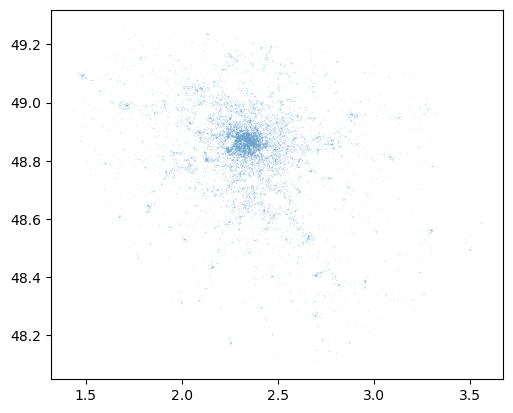

In [90]:
# Concatenate and drop duplicates
unique_coords = gdf_poi[['lon', 'lat']].drop_duplicates()

# Reset index for clarity
unique_coords = unique_coords.reset_index(drop=True)

# Get corresponding h3 id (10) for each coordinate pair
tqdm.pandas(desc="Calculating H3 IDs")
unique_coords['h3_id'] = unique_coords.progress_apply(lambda row: h3.latlng_to_cell(row['lat'], row['lon'], res=10), axis=1)
# Extract unique h3_ids
h3_list = unique_coords['h3_id'].unique().tolist()
polygons = [Polygon(h3.cells_to_geo([x])['coordinates'][0]) for x in h3_list]

# Create a GeoDataFrame from unique h3_ids
gdf_h3 = gpd.GeoDataFrame(
    h3_list,
    geometry=polygons,
    crs="EPSG:4326"
)
gdf_h3.columns= ['h3_id', 'geometry']
gdf_h3.plot()

In [91]:
gdf_poi_r = gpd.sjoin(gdf_poi, gdf_h3)
gdf_poi_r = gdf_poi_r[['id', 'h3_id']]

In [92]:
df_set_r = df_set.merge(gdf_poi_r, left_on='poi_id', right_on='id', how='left')
df_set_r.head()

,ID,poi_id,time_left,mode,id,h3_id
0,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,622054503511457791
1,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,622054503511457791
2,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,622054503511457791
3,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,622054503511457791
4,16_4000,08f1fb4670bb338a03a0f7c1eb8d83f2,2.0,pt,08f1fb4670bb338a03a0f7c1eb8d83f2,622054503511457791


In [93]:
df_set_r = df_set_r.groupby(['ID', 'mode', 'h3_id'])['time_left'].mean().reset_index()

In [94]:
df_set_r.head()

,ID,mode,h3_id,time_left
0,10_2978,car,622054501628674047,2.0
1,10_2978,car,622054501628968959,3.0
2,10_2978,car,622054501631754239,2.0
3,10_2978,car,622054501633851391,1.0
4,10_2978,car,622054501634441215,3.0


In [95]:
df = pd.read_parquet(f'dbs/data_p/stays_extraction_all.parquet')

In [96]:
THIRD = {'LEISURE'}
def third_place_visits_h3(group):
    acts = [group['purpose_o'].tolist()[0]] + group['purpose_d'].tolist()
    # Filter third places
    third_places = [x for x in acts if x in THIRD]
    n = len(third_places)

    if n == 0:
        return pd.Series({'h3_visits': []})
    # --- 2) Build lists of coordinate pairs (lat, lon) ---
    # (a) Flat list of all start+end coords across the whole dataframe
    all_coords = (
        list(zip(group["start_lat"], group["start_lon"])) +
        list(zip(group["end_lat"],   group["end_lon"]))
    )
    # Drop NaNs
    all_coords = [(lat, lon) for lat, lon in all_coords
                if pd.notna(lat) and pd.notna(lon)]

    # --- 3) Corresponding H3 r=10 for those coords (same order as all_coords) ---
    all_h3_r10 = [h3.latlng_to_cell(lat, lon, res=10) for lat, lon in all_coords]
    all_h3_r10 = [h for h in all_h3_r10 if pd.notna(h)]

    return pd.Series({'h3_visits': list(set(all_h3_r10))})

df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\4090252263.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_v = df.groupby('ID').apply(third_place_visits_h3).reset_index()


In [97]:
df_v.head()

,ID,h3_visits
0,10_2978,[]
1,10_2980,"[622054503243612159, 622054503472332799, 62205..."
2,10_2981,"[622054505055289343, 622054238074535935, 62205..."
3,10_2982,"[622054258560368639, 622054258563514367, 62205..."
4,10_2984,"[622054508082135039, 622054508268650495, 62205..."


## 1. Individual sampling

In [98]:
id_list = df_v.ID.values
feasible_id = []
for i in tqdm(id_list):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    if len(set_s) > 0:
        set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
        if len(set_v) > 0:
            feasible_id.append(i)

100%|██████████| 3318/3318 [17:00<00:00,  3.25it/s]


In [99]:
len(set_v), len(set_s)

(16, 3314)

In [100]:
set_s.sort_values(by='time_left', ascending=False, inplace=True)
set_s['rank'] = np.arange(1, len(set_s) + 1)

In [101]:
def mean_rank_test(visited_ids, df_ranked, B=1000, random_seed=42):
    np.random.seed(random_seed)

    feasible_ids = df_ranked['h3_id'].tolist()
    rank_dict = dict(zip(df_ranked['h3_id'], df_ranked['rank']))
    N_i = len(feasible_ids)

    # Filter only visited places within feasible set
    visited_in_spa = [h for h in visited_ids if h in rank_dict]
    k_i = len(visited_in_spa)

    if k_i == 0:
        return {
            'T_mean_act': np.nan,
            'mu_null': np.nan,
            'sigma_null': np.nan,
            'd_i': np.nan,
            'p_empirical': np.nan,
            'note': 'No visited h3_id in SPA'
        }

    T_act = np.mean([rank_dict[h] for h in visited_in_spa])

    null_T = []
    for _ in range(B):
        rand_draw = np.random.choice(feasible_ids, size=k_i, replace=False)
        null_T.append(np.mean([rank_dict[h] for h in rand_draw]))
    null_T = np.array(null_T)

    p_val = (1 + np.sum(null_T <= T_act)) / (B + 1)
    mu_null = np.mean(null_T)
    sigma_null = np.std(null_T, ddof=1)
    d_i = (T_act - mu_null) / sigma_null if sigma_null > 0 else np.nan

    return {
        'T_mean_act': T_act,
        'mu_null': mu_null,
        'sigma_null': sigma_null,
        'd_i': d_i,
        'p_empirical': p_val,
        'k_i': k_i,
        'excluded_visits': len(visited_ids) - k_i
    }

In [104]:
res1 = mean_rank_test(set_v, set_s)
print("Mean Rank Test:", res1)

Mean Rank Test: {'T_mean_act': 527.8571428571429, 'mu_null': 1685.8065714285715, 'sigma_null': 348.2332138115019, 'd_i': -3.325212480157693, 'p_empirical': 0.000999000999000999, 'k_i': 7, 'excluded_visits': 9}


## 2. Scale up to all individuals

In [109]:
test_results = []
for i in tqdm(feasible_id):
    set_s = df_set_r.loc[df_set_r['ID'] == i, :].copy()
    set_v = df_v.loc[df_v['ID'] == i, 'h3_visits'].values[0]  # a list of visited h3_id (unique)
    set_s.sort_values(by='time_left', ascending=False, inplace=True)
    set_s['rank'] = np.arange(1, len(set_s) + 1)
    res1 = mean_rank_test(set_v, set_s)
    res1['ID'] = i
    test_results.append(res1)
df_m = pd.DataFrame(test_results)

100%|██████████| 856/856 [12:23<00:00,  1.15it/s]


In [113]:
df_m.loc[:, 'k_i'].fillna(0, inplace=True)
df_m.loc[:, 'excluded_visits'].fillna(99999, inplace=True)
df_m.head()

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\4213945899.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_m.loc[:, 'k_i'].fillna(0, inplace=True)
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\4213945899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

,T_mean_act,mu_null,sigma_null,d_i,p_empirical,k_i,excluded_visits,ID,note
0,2340.937500,4805.324875,489.055720,-5.039073,0.000999,16.0,4.0,10_2980,NaN
1,1410.571429,2064.605286,418.562458,-1.562572,0.060939,7.0,20.0,10_2984,NaN
2,NaN,NaN,NaN,NaN,NaN,0.0,99999.0,10_2993,No visited h3_id in SPA
3,220.260870,701.002565,84.264339,-5.705162,0.000999,23.0,9.0,10_2994,NaN
4,876.600000,6257.767200,1607.929606,-3.346644,0.000999,5.0,24.0,10_2998,NaN


In [112]:
len(df_m[df_m['k_i'] == 0]) / len(df_m) * 100

2.219626168224299

In [115]:
df_m.loc[:, 'excluded_share'] = df_m.loc[:, 'excluded_visits'] / (df_m.loc[:, 'k_i'] + df_m.loc[:, 'excluded_visits'])
df_m.loc[:, 'excluded_share'] = df_m.apply(lambda row: row['excluded_share'] if row['k_i'] > 0 else 1, axis=1)

In [120]:
df_p = pd.read_csv("dbs/data_p/commuter_model_features_r.csv")
df_p.columns

Index(['ID', 'entropy_mm', 'activity_nh_ratio', 'activity_time_third',
       'total_travel_time', 'xs_total_hws', 'trip_chaining_presence', 'Gender',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'access_h', 'mode', 'ak', 'ak_cat', 'ak_log', 'codgeo', 'pt_sub',
       'entropy_mm_norm', 'id', 'h3_id', 'active_mode'],
      dtype='object')

In [122]:
df_m_r = df_m.merge(df_p[['ID', 'Gender',
       'main_mode_r', 'Age', 'Education', 'Household_type', 'weight_ind',
       'codgeo', 'pt_sub', 'active_mode']], on='ID', how='left')
df_m_r.head()

,T_mean_act,mu_null,sigma_null,d_i,p_empirical,k_i,excluded_visits,ID,note,excluded_share,Gender,main_mode_r,Age,Education,Household_type,weight_ind,codgeo,pt_sub,active_mode
0,2340.937500,4805.324875,489.055720,-5.039073,0.000999,16.0,4.0,10_2980,NaN,0.200000,Man,Active/Micro,30.0,5.0,0.0,1375.000372,75120.0,True,1
1,1410.571429,2064.605286,418.562458,-1.562572,0.060939,7.0,20.0,10_2984,NaN,0.740741,Woman,Car,39.0,5.0,0.0,843.194726,78073.0,True,0
2,NaN,NaN,NaN,NaN,NaN,0.0,99999.0,10_2993,No visited h3_id in SPA,1.000000,Woman,Car,55.0,9.0,6.0,1113.895194,77445.0,False,0
3,220.260870,701.002565,84.264339,-5.705162,0.000999,23.0,9.0,10_2994,NaN,0.281250,Man,Active/Micro,44.0,9.0,6.0,3936.409843,75115.0,True,1
4,876.600000,6257.767200,1607.929606,-3.346644,0.000999,5.0,24.0,10_2998,NaN,0.827586,Man,Car,32.0,4.0,6.0,1528.693295,91587.0,False,0


## 3. Visualize the results

In [127]:
# ----- 1. Effect on entropy_mm -----
model_entropy = smf.ols(
    formula="excluded_share ~ C(pt_sub) + C(active_mode) + C(main_mode_r) + C(Household_type)",    # + Age + C(Education) + C(Gender) +
    data=df_m_r
).fit(weights=df_m_r["weight_ind"])

print("\n--- Entropy_mm model (weighted) ---")
print(model_entropy.summary())


--- Entropy_mm model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:         excluded_share   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     37.06
Date:                Sun, 31 Aug 2025   Prob (F-statistic):           2.28e-60
Time:                        10:50:00   Log-Likelihood:                 83.187
No. Observations:                 856   AIC:                            -144.4
Df Residuals:                     845   BIC:                            -92.10
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [116]:
df_m['excluded_share'].describe()

count    856.000000
mean       0.612669
std        0.263494
min        0.000000
25%        0.411096
50%        0.678571
75%        0.828571
max        1.000000
Name: excluded_share, dtype: float64

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\1239495865.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_m_r.groupby('bin').size()
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\1239495865.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()


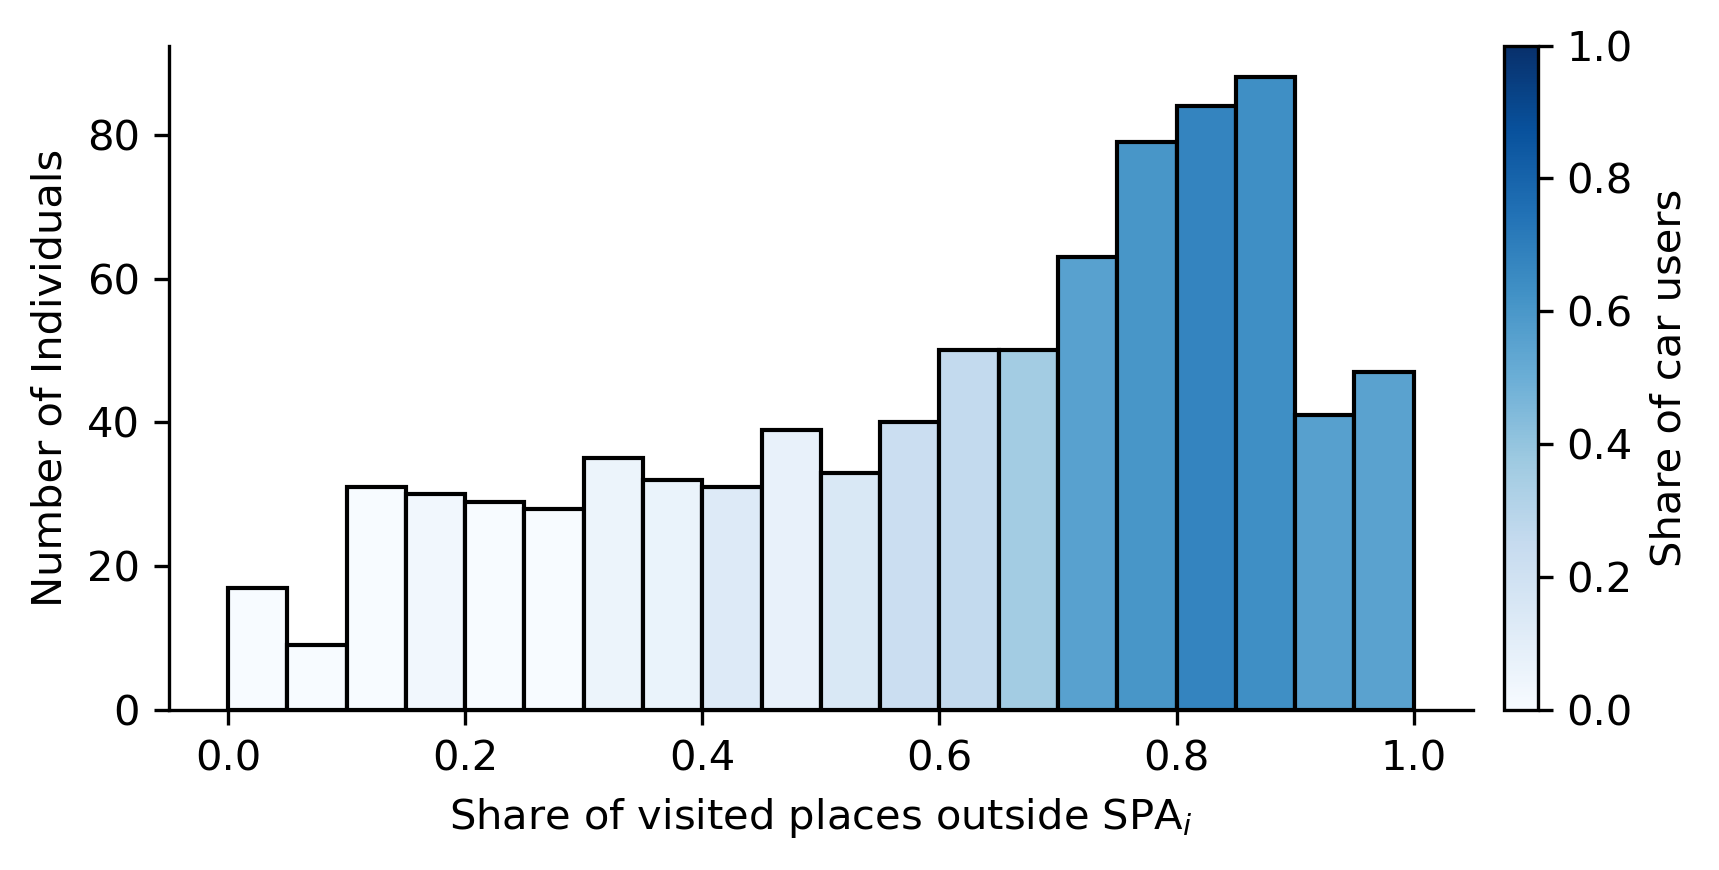

In [234]:
# Step 1: Bin the data
bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
df_m_r['bin'] = pd.cut(df_m_r['excluded_share'], bins=bins, include_lowest=True)

# Step 2: Count total and car users in each bin
bin_counts = df_m_r.groupby('bin').size()
car_counts = df_m_r[df_m_r['main_mode_r'] == 'Car'].groupby('bin').size()

# Align and compute car share
car_share = (car_counts / bin_counts).fillna(0)

# Step 3: Create colored bars using car share
colors = cm.Blues(car_share.values)  # You can change colormap here

# Step 4: Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=300)

# Bar heights (total individuals per bin)
heights = bin_counts.values
lefts = bins[:-1]
width = bins[1] - bins[0]

# Draw bars one by one with color
for i in range(len(heights)):
    ax.bar(lefts[i], heights[i], width=width, align='edge', 
           color=colors[i], edgecolor='black', alpha=1)

# Labels and aesthetics
ax.set_xlabel("Share of visited places outside SPA$_i$")
ax.set_ylabel("Number of Individuals")
# ax.set_title("Distribution of Excluded Visits\nColored by Car User Share")
sns.despine(ax=ax)

sm = cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])  # Needed for ScalarMappable
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Share of car users')

plt.tight_layout()
fig.savefig("figures/selectivity_excluded_share.png", dpi=300, bbox_inches='tight')
plt.show()

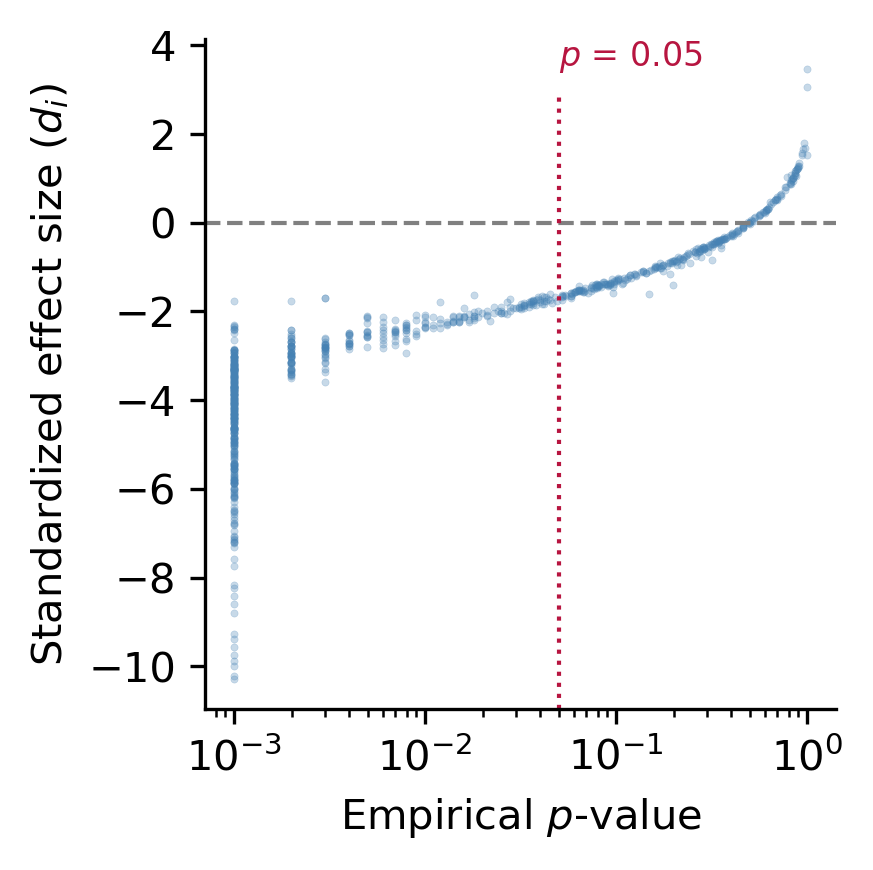

In [240]:
# Drop NaNs
df2plot = df_m_r.dropna(subset=['d_i', 'p_empirical'])

# Set up figure
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Base scatterplot
sns.scatterplot(
    data=df2plot,
    x='p_empirical',
    y='d_i',
    alpha=0.3,
    edgecolor=None,
    s=3,
    color='steelblue'
)

# Reference lines
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0.05, color='#b71540', linestyle=':', linewidth=1)
plt.text(
    0.05,                # x position
    plt.ylim()[1],       # top of the y-axis
    '$p$ = 0.05',          # label text
    color='#b71540',
    ha='left', va='top',
    fontsize=8,
    rotation=0,
    backgroundcolor='white'
)
# Labels and title
plt.xlabel("Empirical $p$-value")
plt.ylabel("Standardized effect size ($d_i$)")
# plt.title("Selectivity in Spatial Choices\n(p-value vs. Effect Size)")

# Clean up
sns.despine()
plt.xscale('log')
plt.tight_layout()
fig.savefig("figures/selectivity_effect_size.png", dpi=300, bbox_inches='tight')
plt.show()

In [170]:
len(df2plot[df2plot['p_empirical'] < 0.05]) / len(df2plot)

0.6650717703349283

In [192]:
cat_dict = {'entropy_mm': 'Leisure activity participation', 
            'activity_time_third': 'Leisure activity participation', 
            'total_travel_time': "Trip making", 'xs_total_hws': "Trip making", 
            'trip_chaining_presence': "Trip making", 
            'Gender': "Individual attributes", 
            #'main_mode_r': "Transport mode", 
            'Age': "Individual attributes", 
            'Education': "Individual attributes", 
            'Household_type': "Individual attributes", 
            'weight_ind': "Individual attributes", 
            'mode': "Transport mode", 
            'ak_cat': "Space-time accessibility", 
            'ak_log': "Space-time accessibility", 
            'pt_sub': "Transport mode", 
            'active_mode': "Individual attributes"}
cat_name_dict = {'entropy_mm': 'Third activity entropy', 
            'activity_time_third': 'Third activity time (min)', 
            'total_travel_time': "Total travel time (min)", 'xs_total_hws': "Trip chaining complexity", 
            'trip_chaining_presence': "Trip chaining presence", 
            'Gender': "Gender", 
            # 'main_mode_r': "Main transport mode", 
            'Age': "Age", 
            'Education': "Education", 
            'Household_type': "Household type", 
            'weight_ind': "Individual attributes", 
            'mode': "Main transport mode", 
            'ak_cat': "Space-time accessibility (> 0)", 
            'ak_log': "Space-time accessibility (log)", 
            'pt_sub': "Public transit subscription", 
            'active_mode': "Use of active mode"}
cat_list = ['trip_chaining_presence', 'Gender', 'Education', 'Household_type', 'mode', 'ak_cat', 'pt_sub', 'active_mode']
cat_level_dict = dict()
Education_dict = {
    'No diploma': 0,
    'Vocational': 1,
    'Lower secondary': 2,
    'Upper secondary': 3,
    '3–4-year higher education': 4,
    "5-year-and-above higher education": 5,
    "Missing": 9
}
household_order = {
    'Other': 0,
    'Other': 1,
    'Single parent': 2,
    'Living with parent(s)': 3,
    'Other': 4,
    'Other': 5,
    'In a couple w/ child(ren)': 6,
    'Other': 7
}
cat_level_dict['Education'] = {v: k for k, v in Education_dict.items()}
cat_level_dict['trip_chaining_presence'] = {0: 'w/o', 1: 'w/'}
cat_level_dict['Gender'] = {'Woman': 'Woman', 'Man': 'Man'}
cat_level_dict['Household_type'] = {v: k for k, v in household_order.items()}
cat_level_dict['mode'] = {'Car': 'Car', 'Public transit': 'Public transit'}
cat_level_dict['ak_cat'] = {'Zero': 'Zero', 'Non-zero': 'Non-zero'}
cat_level_dict['pt_sub'] = {True: 'Yes', False: 'No'}
cat_level_dict['active_mode'] = {1: 'Yes', 0: 'No'}

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\1991132563.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2plot['active_mode'] = df2plot['active_mode'].map(cat_level_dict['active_mode'])
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\1991132563.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2plot['Household_type'] = df2plot['Household_type'].map(cat_level_dict['Household_type'])
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_20396\1991132563.py:9: SettingWithCopyWarning: 
A value is tr

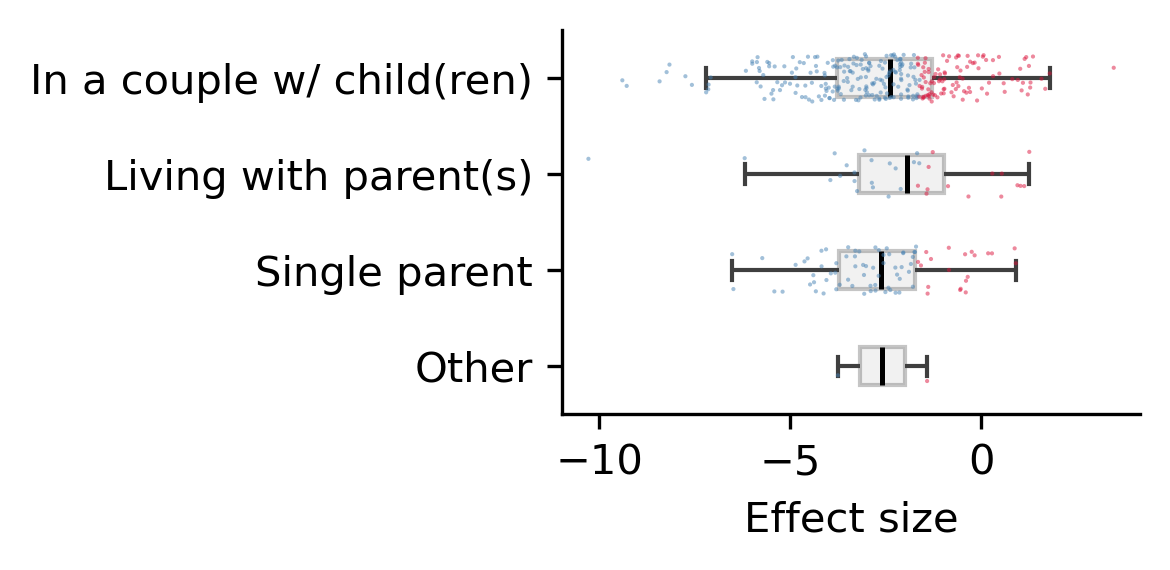

In [242]:
# Drop missing values
df2plot = df_m_r.dropna(subset=['d_i', 'Household_type', 'p_empirical'])

# Map categorical labels if needed
df2plot['active_mode'] = df2plot['active_mode'].map(cat_level_dict['active_mode'])
df2plot['Household_type'] = df2plot['Household_type'].map(cat_level_dict['Household_type'])

# Flag significance
df2plot['is_significant'] = df2plot['p_empirical'] < 0.05

# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    width=0.4,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='Household_type',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("")
plt.xlabel("Effect size")
sns.despine()
plt.tight_layout()
plt.show()

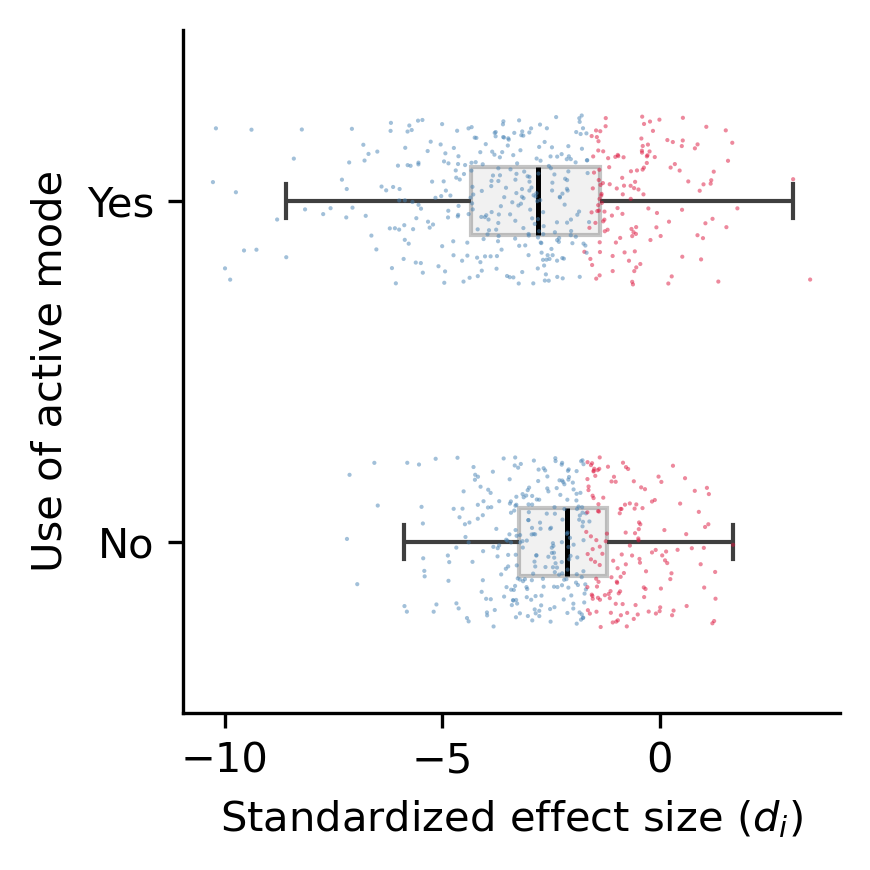

In [243]:
# Set up horizontal plot
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

# Boxplot (horizontal)
sns.boxplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    width=0.2,
    showcaps=True,
    showfliers=False,
    boxprops=dict(alpha=0.3, linewidth=1, facecolor='lightgray'),
    whiskerprops=dict(linewidth=1),
    medianprops=dict(color='black', linewidth=1.2)
)

# Jitter plot overlaid
sns.stripplot(
    data=df2plot,
    y='active_mode',
    x='d_i',
    hue='is_significant',
    palette={False: 'crimson', True: 'steelblue'},
    jitter=0.25,
    dodge=False,
    alpha=0.5,
    size=1,
    legend=False
)

# Labels
plt.ylabel("Use of active mode")
plt.xlabel("Standardized effect size ($d_i$)")
sns.despine()
plt.tight_layout()
fig.savefig("figures/selectivity_active_mode.png", dpi=300, bbox_inches='tight')
plt.show()

In [244]:
# ----- 1. Effect on entropy_mm -----
model_entropy = smf.ols(
    formula="d_i ~ C(main_mode_r) + C(active_mode) + C(Household_type)",
    data=df2plot
).fit(weights=df2plot["weight_ind"])

print("\n--- Effect size model (weighted) ---")
print(model_entropy.summary())


--- Effect size model (weighted) ---
                            OLS Regression Results                            
Dep. Variable:                    d_i   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.922
Date:                Sun, 31 Aug 2025   Prob (F-statistic):             0.0895
Time:                        18:03:13   Log-Likelihood:                -879.17
No. Observations:                 420   AIC:                             1770.
Df Residuals:                     414   BIC:                             1795.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------